In [2]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

# Load imports from the src directory
sys.path.insert(0, "../..")

from progsnap2.spec.enums import MainTableColumns as Cols
import pandas as pd

In [3]:
from progsnap2.analytics.analytics_config import Granularity
from progsnap2.datasets import codeworkout, edwards, codebench, cs1eng

# Select a dataset by setting the config variable
config = codebench.F24

datasets_dir = os.path.join('..', '..', '..', 'sample_data')
dataset_paths = {
    # Edwards 2019 datasets is split into two semesters
    'edwards_f19': os.path.join(datasets_dir, 'edwards', '2019'),
    'edwards_s19': os.path.join(datasets_dir, 'edwards', '2019'),
}

if config.name in dataset_paths:
    dataset_root_dir = dataset_paths[config.name]
else:
    # Most datasets follow a simple naming convention
    dataset_name, dataset_semester = config.name.split('_')
    dataset_root_dir = os.path.join('..', '..', '..', 'sample_data', dataset_name, dataset_semester)

dataset = config.load(dataset_root_dir)

In [4]:
# Shorten some config variables for convenience
problem_id_col = config.primary_problem_grouping_column
timestamp_col = config.primary_timestamp_column

In [5]:
main_table = dataset.get_main_table()
main_table.head()

Removing classes with less than 1000 submissions: [4049259557.0, 919753123.0, 2248339634.0]


,EventID,EventType,Order,SubjectID,CodeStateID,ProjectID,ToolInstances,ServerTimestamp,AssignmentID,ProblemID,...,X-ExecutionTime,ProgramInput,ProgramOutput,X-ProgramCorrectOutput,ProgramErrorOutput,EditType,X-InsertText,SourceLocation,CodeStateSection,ParentEventID
0,1231503,File.Focus,0,1837898832,NaN,NaN,Python 3.8.5; CodeMirror 6,2024-05-12 15:57:04.334,4.070595e+09,9.529734e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main.py,NaN
1,1231504,X-File.Blur,1,1837898832,NaN,NaN,Python 3.8.5; CodeMirror 6,2024-05-12 15:57:36.562,4.070595e+09,9.529734e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main.py,NaN
2,1224514,File.Focus,2,1837898832,NaN,NaN,Python 3.8.5; CodeMirror 6,2024-05-12 15:59:19.589,4.070595e+09,1.471865e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main.py,NaN
3,1224516,File.Edit,3,1837898832,NaN,NaN,Python 3.8.5; CodeMirror 6,2024-05-12 15:59:23.102,4.070595e+09,1.471865e+09,...,NaN,NaN,NaN,NaN,NaN,Insert,NaN,NaN,main.py,NaN
4,1224513,File.Edit,4,1837898832,NaN,NaN,Python 3.8.5; CodeMirror 6,2024-05-12 15:59:23.209,4.070595e+09,1.471865e+09,...,NaN,NaN,NaN,NaN,NaN,Insert,f,Text:1,main.py,NaN


In [6]:
if config.start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= config.start_time]
if config.end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= config.end_time]

In [7]:
# Used for converting percentages to raw early time when
# creating a dataset config; not needed when using existing configs
min = main_table[timestamp_col].min()
max = main_table[timestamp_col].max()
min + (max - min) * 0.29

Timestamp('2024-09-22 21:34:07.087399999')

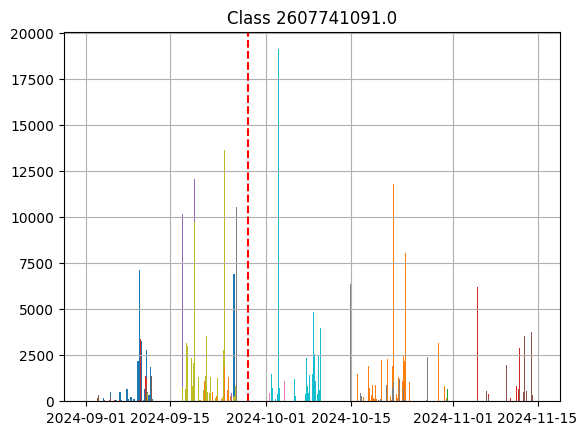

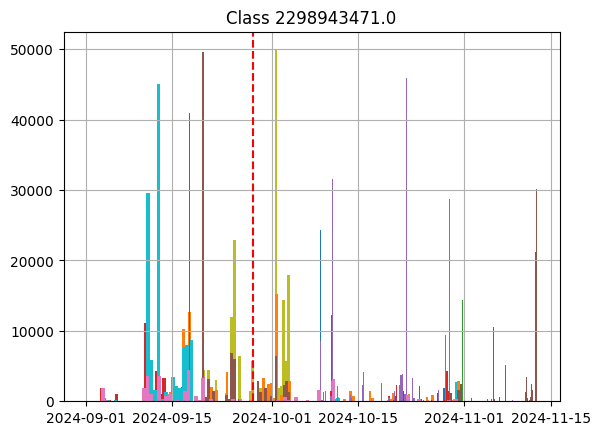

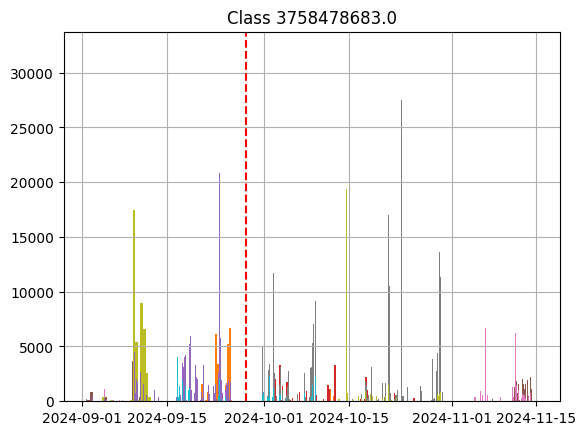

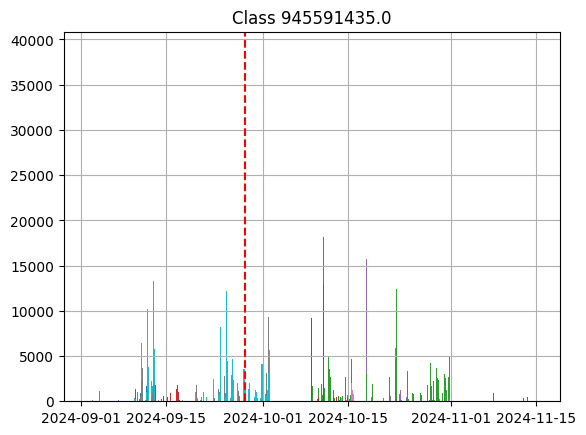

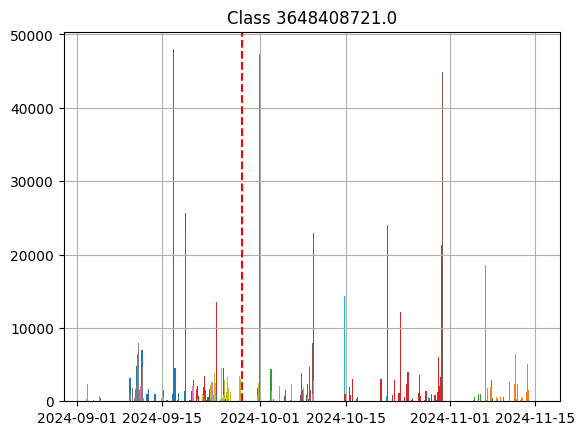

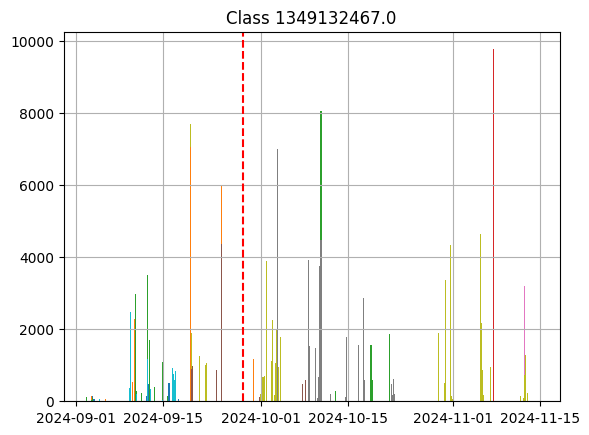

In [8]:
assignment_col = Cols.AssignmentID if Cols.AssignmentID in main_table.columns else problem_id_col
early_timestamp = pd.to_datetime(config.early_time)
if early_timestamp is None:
    print("Warning: No early time cutoff specified")
if Cols.CourseSectionID not in main_table.columns:
    main_table.groupby(assignment_col)[timestamp_col].hist(bins=100)
    if early_timestamp is not None:
        plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
else:
    classes = main_table[Cols.CourseSectionID].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table[Cols.CourseSectionID] == class_id]
        hist = subset.groupby(assignment_col)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        if early_timestamp is not None:
            plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
        plt.show()

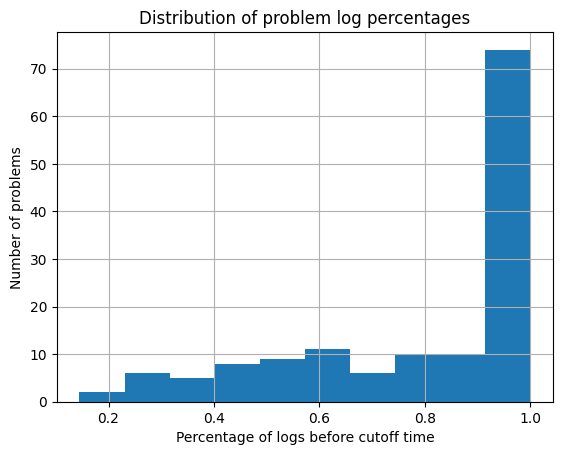

Removing partial problems: Index([  29289889.0, 2112871351.0,  794929878.0, 1265184095.0, 2942877484.0,
       3256357809.0, 3163761635.0, 2880500564.0,  345815840.0, 1726902884.0,
       2211015949.0,  731742138.0, 1005919218.0, 3329775632.0, 2163063328.0,
       2268050633.0, 1882681310.0, 3337648477.0, 4025095144.0, 1959760979.0,
       3239583994.0, 3643348068.0],
      dtype='float64', name='ProblemID')
This removed 2.89% of data
Semester start 2024-09-01 01:35:32.500000
Semester end 2024-11-15 08:24:25.560000
Early cutoff time 2024-09-28 00:00:00
Early Assignment IDs: [2.61168503e+09            nan 2.01335709e+09 4.27067005e+09
 1.36085055e+09 1.36006365e+09 3.09679449e+09 3.46621932e+09
 1.98032895e+09 2.90983374e+08 5.85776055e+08 1.99881010e+07
 5.58149337e+08 7.59078646e+08 2.14537607e+09 1.19249144e+08
 2.40815043e+08 2.74582803e+09 3.68109256e+08 2.78087063e+09
 3.91324454e+09 2.14815632e+09 1.70419381e+09 1.03734466e+09
 2.49103774e+08 3.97028108e+09 1.89665852e+09 4.59282

In [9]:
from progsnap2.analytics.preprocessors.early_cutoff import filter_before_time

data_subset = filter_before_time(main_table, config.early_time, timestamp_col, filter_problems=True, verbose=True)

In [10]:
# We want to analyze each student's attempt at each problem, and we also
# want to analyze data separately from each course section.
grouping_cols = config.attempt_grouping_columns
grouping_cols = [col for col in grouping_cols if col in main_table.columns]
grouping_cols

[<MainTableColumns.SubjectID: 'SubjectID'>,
 <MainTableColumns.AssignmentID: 'AssignmentID'>,
 <MainTableColumns.ProblemID: 'ProblemID'>,
 <MainTableColumns.CourseSectionID: 'CourseSectionID'>,
 <MainTableColumns.CourseID: 'CourseID'>]

In [11]:
from progsnap2.analytics.metrics.errors import ErrorMetrics

error_results = None

if Cols.ParentEventID in data_subset.columns:
    error_metrics = ErrorMetrics(True,
                                compile_message_type_column=config.compile_error_type_column,
                                compile_event=config.compile_event,
                                compile_error_event=config.compile_error_event)

    error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
    error_results.head()

C:\Users\twprice\AppData\Local\Temp\ipykernel_37076\259750463.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)


In [12]:
if error_results is not None:
    # Distribution of each error metric across students/problems
    error_results.describe()

In [13]:
if error_results is not None:
    # Correlate the metrics
    error_results.corr(method="spearman")

<Axes: ylabel='Frequency'>

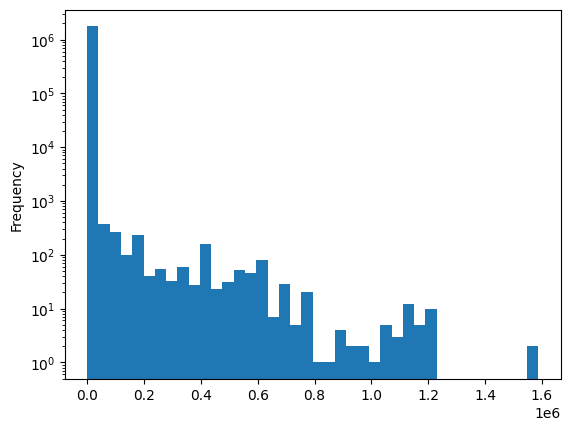

In [14]:
from progsnap2.analytics.metrics.time import TimeMetrics

# Out of curisosity, how far apart are events in this dataset (in seconds)?
diffs = TimeMetrics.get_all_diffs(data_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [15]:
# Determine a gap to be considered idle time or taking a break based
# on the type of dataset. Can confirm with the histogram above if it makes sense
idle_gap = None
break_gap = None
if config.granularity == Granularity.Submission:
    idle_gap = 5 * 60  # 5 minutes
    break_gap = 30 * 60  # 30 minutes
elif config.granularity == Granularity.Edit or config.granularity == Granularity.Keystroke:
    idle_gap = 30
    break_gap = 3 * 60 # 3 minutes
else:
    raise NotImplementedError(f"{config.granularity} granularity has not been determined.")


In [16]:
from progsnap2.analytics.metrics.time import TimeMetrics
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
time_results

C:\Users\twprice\AppData\Local\Temp\ipykernel_37076\1574692767.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  \
SubjectID  AssignmentID ProblemID    CourseSectionID CourseID                  
13108823   4.592827e+08 1.076448e+09 2.298943e+09    218908526.0     279.926   
28270295   2.408150e+08 1.076448e+09 3.648409e+09    218908526.0       0.000   
           2.909834e+08 7.049834e+08 3.648409e+09    218908526.0       0.000   
                        7.758383e+08 3.648409e+09    218908526.0       0.000   
                        1.078076e+09 3.648409e+09    218908526.0       0.000   
...                                                                      ...   
4275215466 1.538637e+09 1.417621e+09 1.349132e+09    218908526.0     152.585   
                        2.249046e+09 1.349132e+09    218908526.0     361.852   
                        3.900747e+09 1.349132e+09    218908526.0     154.119   
           2.455319e+09 2.546841e+08 1.349132e+09    218908526.0     171.571   
                        3.974738e+09 1.349132e+09    218908526.0      59.602   

                                                                  PassiveTime  \
SubjectID  AssignmentID ProblemID    CourseSectionID CourseID                   
13108823   4.592827e+08 1.076448e+09 2.298943e+09    218908526.0      161.617   
28270295   2.408150e+08 1.076448e+09 3.648409e+09    218908526.0        0.000   
           2.909834e+08 7.049834e+08 3.648409e+09    218908526.0        0.000   
                        7.758383e+08 3.648409e+09    218908526.0        0.000   
                        1.078076e+09 3.648409e+09    218908526.0        0.000   
...                                                                       ...   
4275215466 1.538637e+09 1.417621e+09 1.349132e+09    218908526.0       76.344   
                        2.249046e+09 1.349132e+09    218908526.0      174.451   
                        3.900747e+09 1.349132e+09    218908526.0        0.000   
           2.455319e+09 2.546841e+08 1.349132e+09    218908526.0      154.387   
                        3.974738e+09 1.349132e+09    218908526.0        0.000   

                                                                  TotalTime  \
SubjectID  AssignmentID ProblemID    CourseSectionID CourseID                 
13108823   4.592827e+08 1.076448e+09 2.298943e+09    218908526.0    441.543   
28270295   2.408150e+08 1.076448e+09 3.648409e+09    218908526.0      0.000   
           2.909834e+08 7.049834e+08 3.648409e+09    218908526.0      0.000   
                        7.758383e+08 3.648409e+09    218908526.0      0.000   
                        1.078076e+09 3.648409e+09    218908526.0      0.000   
...                                                                     ...   
4275215466 1.538637e+09 1.417621e+09 1.349132e+09    218908526.0    228.929   
                        2.249046e+09 1.349132e+09    218908526.0    536.303   
                        3.900747e+09 1.349132e+09    218908526.0    154.119   
           2.455319e+09 2.546841e+08 1.349132e+09    218908526.0    325.958   
                        3.974738e+09 1.349132e+09    218908526.0     59.602   

                                                                  ActiveTimeAfterCorrect  \
SubjectID  AssignmentID ProblemID    CourseSectionID CourseID                              
13108823   4.592827e+08 1.076448e+09 2.298943e+09    218908526.0                   0.000   
28270295   2.408150e+08 1.076448e+09 3.648409e+09    218908526.0                   0.000   
           2.909834e+08 7.049834e+08 3.648409e+09    218908526.0                   0.000   
                        7.758383e+08 3.648409e+09    218908526.0                   0.000   
                        1.078076e+09 3.648409e+09    218908526.0                   0.000   
...                                                                                  ...   
4275215466 1.538637e+09 1.417621e+09 1.349132e+09    218908526.0                   7.348   
                        2.249046e+09 1.349132e+09    218908526.0                   0.000   
                       

In [17]:
time_results.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,8.053000e+03,8053.000000,8053.000000,8053.000000,8053.000000,8053,7190,8053
mean,2.927335e+02,173.778285,466.511781,9.903354,0.661989,2024-09-13 04:23:28.588503040,2024-09-13 01:49:41.524016640,2024-09-13 20:39:12.446660352
min,-5.684342e-14,0.000000,0.000000,0.000000,0.000000,2024-09-01 01:35:32.500000,2024-09-01 03:52:26.560000,2024-09-01 03:52:26.560000
25%,9.900000e-01,0.000000,27.060000,0.000000,0.000000,2024-09-05 14:06:37.060000,2024-09-05 01:05:44.987500032,2024-09-08 17:43:09.870000128
50%,1.731140e+02,60.758000,246.112000,0.000000,0.000000,2024-09-11 22:16:13.798000128,2024-09-11 19:26:09.234999808,2024-09-12 17:52:57.910000128
75%,4.037910e+02,221.746000,617.174000,0.000000,1.000000,2024-09-18 18:48:08.063000064,2024-09-18 18:59:01.807500032,2024-09-19 00:33:37.560000
max,6.947802e+03,6630.387000,13578.189000,1511.286000,51.000000,2024-09-27 23:30:48.935000,2024-09-27 23:27:23.930000,2024-09-27 23:59:59.997000
std,4.193758e+02,308.362001,686.687108,55.870472,1.550921,NaN,NaN,NaN


<Axes: >

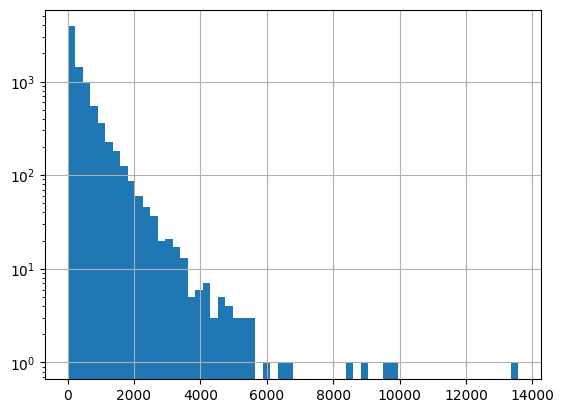

In [18]:
time_results.TotalTime.hist(bins=60, log=True)

In [24]:
main_table.columns

Index(['EventID', 'EventType', 'Order', 'SubjectID', 'CodeStateID',
       'ProjectID', 'ToolInstances', 'ServerTimestamp', 'AssignmentID',
       'ProblemID', 'CourseID', 'CourseSectionID', 'Score', 'Attempt',
       'ExecutionID', 'ExecutionResult', 'X-ExecutionTime', 'ProgramInput',
       'ProgramOutput', 'X-ProgramCorrectOutput', 'ProgramErrorOutput',
       'EditType', 'X-InsertText', 'SourceLocation', 'CodeStateSection',
       'ParentEventID'],
      dtype='object')

In [29]:
main_table.ProblemID = main_table.ProblemID.astype('Int64')

In [41]:
main_table[(main_table[Cols.SubjectID] == 28270295) & (main_table[Cols.ProblemID] == 1076448396)][[Cols.EventType, timestamp_col, Cols.Score, Cols.CodeStateID, "X-InsertText"]].head(50)

,EventType,ServerTimestamp,Score,CodeStateID,X-InsertText
47456,Submit,2024-09-04 18:24:28.910,1.0,f7e22b9591afd3954117b0f1a4cc6f3d9bc20e26,NaN
47457,Run.Test,2024-09-04 18:24:28.910,NaN,f7e22b9591afd3954117b0f1a4cc6f3d9bc20e26,NaN
47458,Run.Test,2024-09-04 18:24:28.910,NaN,f7e22b9591afd3954117b0f1a4cc6f3d9bc20e26,NaN
47459,Run.Test,2024-09-04 18:24:28.910,NaN,f7e22b9591afd3954117b0f1a4cc6f3d9bc20e26,NaN


C:\Users\twprice\AppData\Local\Temp\ipykernel_37076\822233931.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  main_table.groupby([Cols.CourseSectionID]).apply(lambda x: (x[Cols.EventType] == "File.Edit").mean()).hist()


<Axes: >

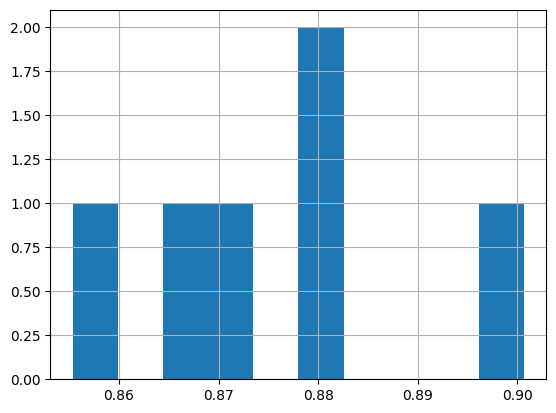

In [57]:
main_table.groupby([Cols.CourseSectionID]).apply(lambda x: (x[Cols.EventType] == "File.Edit").mean()).hist()

In [43]:
main_table[(main_table[Cols.SubjectID] == 28270295) & (main_table[Cols.AssignmentID] == 240815043.0)][[Cols.EventType, Cols.ProblemID, timestamp_col, Cols.Score, Cols.CodeStateID, "X-InsertText"]].head(50)

,EventType,ProblemID,ServerTimestamp,Score,CodeStateID,X-InsertText
47456,Submit,1076448396,2024-09-04 18:24:28.910,1.0,f7e22b9591afd3954117b0f1a4cc6f3d9bc20e26,NaN
47457,Run.Test,1076448396,2024-09-04 18:24:28.910,NaN,f7e22b9591afd3954117b0f1a4cc6f3d9bc20e26,NaN
47458,Run.Test,1076448396,2024-09-04 18:24:28.910,NaN,f7e22b9591afd3954117b0f1a4cc6f3d9bc20e26,NaN
47459,Run.Test,1076448396,2024-09-04 18:24:28.910,NaN,f7e22b9591afd3954117b0f1a4cc6f3d9bc20e26,NaN
2047439,File.Focus,4011687730,2024-09-30 18:05:00.549,NaN,NaN,NaN
2047455,File.Edit,4011687730,2024-09-30 18:05:02.891,NaN,NaN,\n
2047541,File.Edit,4011687730,2024-09-30 18:05:39.820,NaN,NaN,l
2047543,File.Edit,4011687730,2024-09-30 18:05:40.171,NaN,NaN,i
2047544,File.Edit,4011687730,2024-09-30 18:05:40.650,NaN,NaN,t
2047545,File.Edit,4011687730,2024-09-30 18:05:40.969,NaN,NaN,r


In [21]:
print(dataset.get_codestates(main_table[(main_table[Cols.SubjectID] == 28270295) & (main_table[Cols.AssignmentID] == 240815043.0)]).Code.iloc[0])

a = float(input("Digite o valor de a: "))
b = float(input("Digite o valor de b: "))
c = float(input("Digite o valor de c: "))

denominador = (a**2 + b**2 + c**2)
divisor = (a + b + c)
total = denominador / divisor

print(round(total, 7))



In [36]:
ts = time_results.reset_index()
ts[Cols.ProblemID] = ts[Cols.ProblemID].astype('Int64')

In [38]:
print((ts.TotalTime == 0).mean())
ts[ts.TotalTime == 0]

0.20899043834595804


,SubjectID,AssignmentID,ProblemID,CourseSectionID,CourseID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
1,28270295,240815043.0,1076448396,3.648409e+09,218908526.0,0.0,0.0,0.0,0.000,0,2024-09-04 18:24:28.910,2024-09-04 18:24:28.910,2024-09-04 18:24:28.910
2,28270295,290983374.0,704983377,3.648409e+09,218908526.0,0.0,0.0,0.0,0.000,0,2024-09-02 18:19:14.760,2024-09-02 18:19:14.760,2024-09-02 18:19:14.760
3,28270295,290983374.0,775838323,3.648409e+09,218908526.0,0.0,0.0,0.0,0.000,0,2024-09-04 19:00:45.720,2024-09-04 19:00:45.720,2024-09-04 19:00:45.720
4,28270295,290983374.0,1078076002,3.648409e+09,218908526.0,0.0,0.0,0.0,0.000,0,2024-09-04 18:53:21.230,2024-09-04 18:53:21.230,2024-09-04 18:53:21.230
5,28270295,290983374.0,1927446959,3.648409e+09,218908526.0,0.0,0.0,0.0,0.000,0,2024-09-02 19:36:43.750,2024-09-02 19:36:43.750,2024-09-02 19:36:43.750
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8030,4275215466,119249144.0,854576230,1.349132e+09,218908526.0,0.0,0.0,0.0,0.000,0,2024-09-03 13:13:50.590,2024-09-03 13:13:50.590,2024-09-03 13:13:50.590
8031,4275215466,119249144.0,1964285824,1.349132e+09,218908526.0,0.0,0.0,0.0,0.000,0,2024-09-03 13:09:05.380,2024-09-03 13:09:05.380,2024-09-03 13:09:05.380
8032,4275215466,119249144.0,3444416998,1.349132e+09,218908526.0,0.0,0.0,0.0,0.000,0,2024-09-03 13:05:33.660,2024-09-03 13:05:33.660,2024-09-03 13:05:33.660
8035,4275215466,119249144.0,3940197836,1.349132e+09,218908526.0,0.0,0.0,0.0,0.000,0,2024-09-03 13:12:09.560,2024-09-03 13:12:09.560,2024-09-03 13:12:09.560


In [37]:
time_results.corr(method="spearman")

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
ActiveTime,1.000000,0.882878,0.976318,0.068138,0.611957,0.323876,0.240716,0.357750
PassiveTime,0.882878,1.000000,0.960295,0.031926,0.648941,0.321737,0.220118,0.359931
TotalTime,0.976318,0.960295,1.000000,0.046946,0.645738,0.335005,0.237190,0.372241
ActiveTimeAfterCorrect,0.068138,0.031926,0.046946,1.000000,-0.042329,0.058725,0.352376,0.070360
#Breaks,0.611957,0.648941,0.645738,-0.042329,1.000000,0.228897,0.097589,0.329653
StartTime,0.323876,0.321737,0.335005,0.058725,0.228897,1.000000,0.681328,0.956489
FirstCorrectTime,0.240716,0.220118,0.237190,0.352376,0.097589,0.681328,1.000000,0.658524
EndTime,0.357750,0.359931,0.372241,0.070360,0.329653,0.956489,0.658524,1.000000


In [38]:
from progsnap2.analytics.metrics.score import SubmissionScoreMetrics
from progsnap2.spec.enums import EventType

score_metrics = SubmissionScoreMetrics(config.submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_25052\3695921909.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [39]:
subject_problem_score.head()

Attempts  FirstCorrect  EverCorrect  Attempted  \
SubjectID     ProblemID                                                   
Passion Fruit homework2         7         False         True       True   
              homework3         4         False         True       True   
              homework4        11         False         True       True   
              homework5        10         False         True       True   
              inlab2            3         False        False       True   

                         MaxScore  MinScore  MeanScore  TotalAttempts  
SubjectID     ProblemID                                                
Passion Fruit homework2  1.000000  0.166667   0.285714             17  
              homework3  1.000000  0.166667   0.375000              9  
              homework4  1.000000  0.166667   0.393939             22  
              homework5  1.000000  0.166667   0.250000             18  
              inlab2     0.166667  0.166667   0.166667              3

In [40]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,379.000000,379.000000,379.000000,379.000000,379.000000
mean,18.240106,0.865076,0.277525,0.440388,21.957784
std,27.510323,0.295107,0.302701,0.279842,30.761900
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.000000,0.166667,0.212963,7.000000
50%,11.000000,1.000000,0.166667,0.361111,15.000000
75%,24.000000,1.000000,0.166667,0.583333,27.000000
max,398.000000,1.000000,1.000000,1.000000,460.000000


In [41]:
all_features = pd.merge(
    time_results.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
if error_results is not None:
    all_features = pd.merge(
        all_features,
        error_results.reset_index(),
        on=grouping_cols,
        how="outer"
    )
all_features.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
0,Passion Fruit,homework2,1260.0,644.0,1904.0,412.0,2,2024-01-18 22:19:18,2024-01-20 23:44:58,2024-01-25 17:42:54,7,False,True,True,1.000000,0.166667,0.285714,17
1,Passion Fruit,homework3,1347.0,872.0,2219.0,572.0,2,2024-01-25 17:48:43,2024-01-27 23:26:16,2024-01-29 17:07:45,4,False,True,True,1.000000,0.166667,0.375000,9
2,Passion Fruit,homework4,2417.0,1217.0,3634.0,188.0,3,2024-01-31 23:50:29,2024-02-04 01:25:05,2024-02-04 02:07:34,11,False,True,True,1.000000,0.166667,0.393939,22
3,Passion Fruit,homework5,878.0,1101.0,1979.0,159.0,1,2024-02-10 21:03:26,2024-02-10 21:52:59,2024-02-10 22:03:24,10,False,True,True,1.000000,0.166667,0.250000,18
4,Passion Fruit,inlab2,700.0,253.0,953.0,0.0,0,2024-01-17 22:07:04,NaT,2024-01-17 22:22:57,3,False,False,True,0.166667,0.166667,0.166667,3


In [42]:
# Some features are NA for some students, e.g. because
# they never got a problem right (no FirstCorrectTime) or
# because they only compiled once and errors metrics are undefined.
all_features.isna().mean()

SubjectID                 0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.197889
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
dtype: float64

In [43]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)

# We can calculate a few custom metrics
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,379.000000,379.000000,379.000000,379.000000,379.000000,379,304,379,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000
mean,1085.488127,794.707124,1880.195251,148.548813,2.427441,2024-01-29 07:31:16.395778304,2024-01-30 02:10:04.575657728,2024-01-30 07:41:22.609498624,18.240106,0.865076,0.277525,0.440388,21.957784,0.503958,0.873351,0.926121
min,0.000000,0.000000,0.000000,0.000000,0.000000,2024-01-17 18:59:34,2024-01-17 19:43:42,2024-01-17 19:16:48,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,344.500000,179.500000,573.000000,0.000000,0.000000,2024-01-24 13:50:36,2024-01-24 20:09:55,2024-01-24 20:14:14.500000,4.000000,1.000000,0.166667,0.212963,7.000000,0.000000,1.000000,1.000000
50%,852.000000,592.000000,1432.000000,16.000000,1.000000,2024-01-29 23:15:53,2024-01-30 08:18:21.500000,2024-01-31 19:46:57,11.000000,1.000000,0.166667,0.361111,15.000000,1.000000,1.000000,1.000000
75%,1562.500000,1057.500000,2720.500000,188.500000,3.000000,2024-02-05 18:20:50,2024-02-06 18:01:57,2024-02-06 20:08:40,24.000000,1.000000,0.166667,0.583333,27.000000,1.000000,1.000000,1.000000
max,6857.000000,4757.000000,10985.000000,2782.000000,16.000000,2024-02-11 03:31:26,2024-02-11 04:00:48,2024-02-11 20:40:59,398.000000,1.000000,1.000000,1.000000,460.000000,1.000000,1.000000,1.000000
std,991.829242,836.058627,1761.698987,301.284735,3.170947,NaN,NaN,NaN,27.510323,0.295107,0.302701,0.279842,30.761900,0.500645,0.333019,0.261919


In [44]:
# Let's take the z-score per problem for each numeric feature to
# normalize the features before combining across problems.
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [45]:
all_features_z.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,Passion Fruit,homework2,2.815684,1.378043,2.225294,2.923711,2.322328,-0.406223,0.715004,1.645119,...,False,True,True,0.000000,-0.962102,-1.247063,1.367346,0.962102,0.000000,0.000000
1,Passion Fruit,homework3,0.173264,-0.063205,0.061599,0.992174,-0.501001,0.057559,0.432092,0.950133,...,False,True,True,0.425602,-0.418050,-0.009225,-0.727957,0.989949,0.432049,0.250106
2,Passion Fruit,homework4,1.440517,0.500816,1.033491,-0.068596,-0.078499,-0.140295,0.323074,1.021858,...,False,True,True,0.304132,-0.542105,-0.736603,0.221365,0.990338,0.323013,0.198068
3,Passion Fruit,homework5,-0.420726,-0.091841,-0.268859,0.033233,-0.785734,1.426276,0.413195,0.953716,...,False,True,True,0.392202,-0.240279,-0.175368,-0.343557,-0.990697,0.413149,0.316467
4,Passion Fruit,inlab2,0.366703,-0.431493,-0.084364,-0.413413,-0.802643,-0.420186,-0.814944,-0.514432,...,False,False,True,-0.812079,-0.283824,-0.508699,-0.745700,0.968475,0.145865,0.145865


In [50]:
merge_cols = grouping_cols.copy()
merge_cols = [col for col in merge_cols if col not in [Cols.ProblemID, Cols.AssignmentID]]
merge_cols = [col for col in merge_cols if col in all_features_z.columns]
drop_cols = [col for col in [Cols.ProblemID, Cols.AssignmentID] if col in all_features_z.columns]

# Take the average across all problems for each student
subject_means = all_features_z.drop(drop_cols, axis=1).groupby(merge_cols).mean()

# Sometimes there are no non-NA values for a student across all problems for a given
# feature and we need to deal with that.

# For EQ and RED having no attempts with a successful compile (and therefore a score)
# should give you the max (worst) value
for col in [ErrorMetrics.ERROR_QUOTIENT, ErrorMetrics.REPEATED_ERROR_DENSITY]:
    if col not in subject_means.columns:
        continue
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for score metrics, not trying a problem should lead to the minimum value
for col in [SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,
Passion Fruit,0.875089,0.258464,0.593432,0.693422,0.030890,0.103426,0.213684,0.811279,-0.344297,0.000000,0.800000,1.000,0.061971,-0.489272,-0.535392,-0.045701,0.584033,0.262815,0.182101
Acerola Cherry,-0.491926,-0.701188,-0.622145,0.166407,-0.193855,1.043080,0.264235,0.447868,-0.720393,0.250000,0.875000,0.875,0.058678,0.374375,0.369958,-0.732418,-0.750332,0.031614,-0.105134
Ackee,-0.705926,-0.662659,-0.720804,0.332604,-0.602141,0.027919,0.082809,-0.423581,-0.640035,0.333333,0.833333,1.000,-0.008799,0.497738,0.732993,-0.374306,-0.993257,-0.093032,-0.325835
Apple,-0.365644,-0.090010,-0.256734,0.327787,-0.190765,-0.834637,-0.082966,-0.815120,-0.455895,0.000000,0.857143,1.000,0.089692,-0.197235,0.038753,-0.352864,-0.147976,0.077794,-0.082627
Apricot,-0.423474,-0.208400,-0.333801,-0.393014,0.036087,0.428940,0.318335,0.355756,-0.310952,0.250000,0.875000,1.000,0.190391,0.373772,0.312082,-0.374413,-0.503236,0.340623,0.235904


In [52]:
# We can also take the sum of features across problems, which treats
# missing problems differently than the mean.
subject_totals = all_features_z.drop(drop_cols, axis=1).groupby(merge_cols).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,
Passion Fruit,4.375443,1.292320,2.967160,3.467109,0.154451,0.517131,1.068420,4.056393,-1.721483,0,4,5,0.309857,-2.446361,-2.676958,-0.228504,2.920167,1.314076,0.910506
Acerola Cherry,-3.935406,-5.609504,-4.977162,1.331259,-1.550836,8.344638,2.113880,3.582941,-5.763142,2,7,7,0.469422,2.995000,2.959663,-5.859347,-6.002654,0.252914,-0.841068
Ackee,-4.235555,-3.975953,-4.324826,1.995624,-3.612844,0.167514,0.496855,-2.541484,-3.840212,2,5,6,-0.052795,2.986430,4.397958,-2.245834,-5.959540,-0.558191,-1.955013
Apple,-2.559509,-0.630073,-1.797135,2.294510,-1.335357,-5.842459,-0.580760,-5.705837,-3.191266,0,6,7,0.627845,-1.380648,0.271269,-2.470051,-1.035835,0.544558,-0.578388
Apricot,-3.387789,-1.667201,-2.670409,-3.144111,0.288696,3.431516,2.546683,2.846044,-2.487616,2,7,8,1.523128,2.990179,2.496657,-2.995307,-4.025888,2.724980,1.887229


In [53]:
# Lets merge the means and totals into a single DataFrame
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Passion Fruit,0.875089,0.258464,0.593432,0.693422,0.030890,0.103426,0.213684,0.811279,-0.344297,...,0,4,5,0.309857,-2.446361,-2.676958,-0.228504,2.920167,1.314076,0.910506
1,Acerola Cherry,-0.491926,-0.701188,-0.622145,0.166407,-0.193855,1.043080,0.264235,0.447868,-0.720393,...,2,7,7,0.469422,2.995000,2.959663,-5.859347,-6.002654,0.252914,-0.841068
2,Ackee,-0.705926,-0.662659,-0.720804,0.332604,-0.602141,0.027919,0.082809,-0.423581,-0.640035,...,2,5,6,-0.052795,2.986430,4.397958,-2.245834,-5.959540,-0.558191,-1.955013
3,Apple,-0.365644,-0.090010,-0.256734,0.327787,-0.190765,-0.834637,-0.082966,-0.815120,-0.455895,...,0,6,7,0.627845,-1.380648,0.271269,-2.470051,-1.035835,0.544558,-0.578388
4,Apricot,-0.423474,-0.208400,-0.333801,-0.393014,0.036087,0.428940,0.318335,0.355756,-0.310952,...,2,7,8,1.523128,2.990179,2.496657,-2.995307,-4.025888,2.724980,1.887229


In [54]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [55]:
# No feature should be NA at this point
assert subject_features.isna().mean().mean() == 0

In [56]:
# Take one last z-score across all students for each numeric feature
# This makes means and sums more comparable across students
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Passion Fruit,1.701556,0.451153,1.115622,1.554326,0.024241,0.116226,0.504041,1.343080,-0.544138,...,-0.891164,-0.803832,-0.994490,0.108753,-0.747467,-0.719715,-0.062205,0.828719,0.450992,0.386005
1,Acerola Cherry,-0.871233,-1.227171,-1.111274,0.381027,-0.356764,1.574696,0.617236,0.735870,-1.101808,...,1.028266,0.884216,0.165748,0.164757,0.915099,0.795722,-1.595082,-1.703503,0.086800,-0.356568
2,Ackee,-1.273992,-1.159788,-1.292014,0.751033,-1.048923,-0.000972,0.210984,-0.720199,-0.982655,...,1.028266,-0.241150,-0.414371,-0.018530,0.912481,1.182415,-0.611380,-1.691267,-0.191572,-0.828820
3,Apple,-0.633565,-0.158289,-0.441853,0.740309,-0.351527,-1.339776,-0.160222,-1.374406,-0.709615,...,-0.891164,0.321533,0.165748,0.220359,-0.421847,0.072932,-0.672419,-0.293961,0.186893,-0.245205
4,Apricot,-0.742402,-0.365340,-0.583038,-0.864420,0.033051,0.621467,0.738378,0.581964,-0.494695,...,1.028266,0.884216,0.745868,0.534584,0.913626,0.671240,-0.815408,-1.142513,0.935215,0.800084


In [58]:
# Get the grades to compare features to
grades = dataset.get_link_table(config.grades_link_table_name)
grades.head()

,SubjectID,IsInterventionGroup,MidtermExamGrade,FinalExamGrade,CourseGrade
0,Cherry,0,71.65,78.4,86.68
1,Apple,0,84.30,81.2,93.94
2,Ackee,1,98.50,98.2,99.38
3,Date,1,97.60,93.4,95.65
4,Apricot,0,63.05,64.3,87.37


In [59]:
grades.rename(columns={
    config.final_grade_column: "Grade",
}, inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 0 rows with 0 grades


In [60]:
grade_merge_cols = [col for col in merge_cols if col in grades.columns]
print(f"Merging on columns: {grade_merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[grade_merge_cols + ["Grade"]],
    on=grade_merge_cols,
    how="inner",
)

Merging on columns: [<MainTableColumns.SubjectID: 'SubjectID'>]


In [61]:
print(subject_features.shape)
subject_feautres_labeled.head()

(56, 39)


,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,Passion Fruit,1.701556,0.451153,1.115622,1.554326,0.024241,0.116226,0.504041,1.343080,-0.544138,...,-0.803832,-0.994490,0.108753,-0.747467,-0.719715,-0.062205,0.828719,0.450992,0.386005,71.9
1,Acerola Cherry,-0.871233,-1.227171,-1.111274,0.381027,-0.356764,1.574696,0.617236,0.735870,-1.101808,...,0.884216,0.165748,0.164757,0.915099,0.795722,-1.595082,-1.703503,0.086800,-0.356568,77.9
2,Ackee,-1.273992,-1.159788,-1.292014,0.751033,-1.048923,-0.000972,0.210984,-0.720199,-0.982655,...,-0.241150,-0.414371,-0.018530,0.912481,1.182415,-0.611380,-1.691267,-0.191572,-0.828820,98.2
3,Apple,-0.633565,-0.158289,-0.441853,0.740309,-0.351527,-1.339776,-0.160222,-1.374406,-0.709615,...,0.321533,0.165748,0.220359,-0.421847,0.072932,-0.672419,-0.293961,0.186893,-0.245205,81.2
4,Apricot,-0.742402,-0.365340,-0.583038,-0.864420,0.033051,0.621467,0.738378,0.581964,-0.494695,...,0.884216,0.745868,0.534584,0.913626,0.671240,-0.815408,-1.142513,0.935215,0.800084,64.3


In [62]:
subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().describe()

count    56.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: Grade, dtype: float64

In [63]:
assert subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().max() == 1

In [64]:

out_dir = os.path.join("..", "..", "..", "analysis", "features")
print(len(subject_feautres_labeled))
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
subject_feautres_labeled.to_csv(os.path.join(out_dir, f"{config.name}.csv"), index=False)

56
